In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.interpolate import interp1d
from scipy.optimize import brentq

plt.rcParams.update({
    "font.size": 14,                 # 全局字号
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "xtick.direction": "in",         # 刻度朝内
    "ytick.direction": "in",
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "figure.figsize": (5, 4),        # 图片默认大小
})

In [3]:
df = pd.read_csv("summary_all.csv")
df = df[(df['T'] >= 0.005) & (df['T'] <= 0.100)].sort_values('T')

rho_col = 'Superfluid_Stiffness_mean'
rho_err_col = 'Superfluid_Stiffness_err' if 'Superfluid_Stiffness_err' in df.columns else None
Tc = np.nan
if rho_col in df.columns and len(df) >= 2:
    diff = df[rho_col].to_numpy() - (2 / np.pi) * df['T'].to_numpy()
    finite = np.isfinite(diff)
    if np.any(finite[:-1] & finite[1:] & (diff[:-1] * diff[1:] <= 0)):
        diff_func = interp1d(df['T'], diff, kind='linear')
        Tc = brentq(diff_func, df['T'].min(), df['T'].max())


No twist stiffness columns found. Run batch_process_csv.jl after measure_twist=true jobs finish.


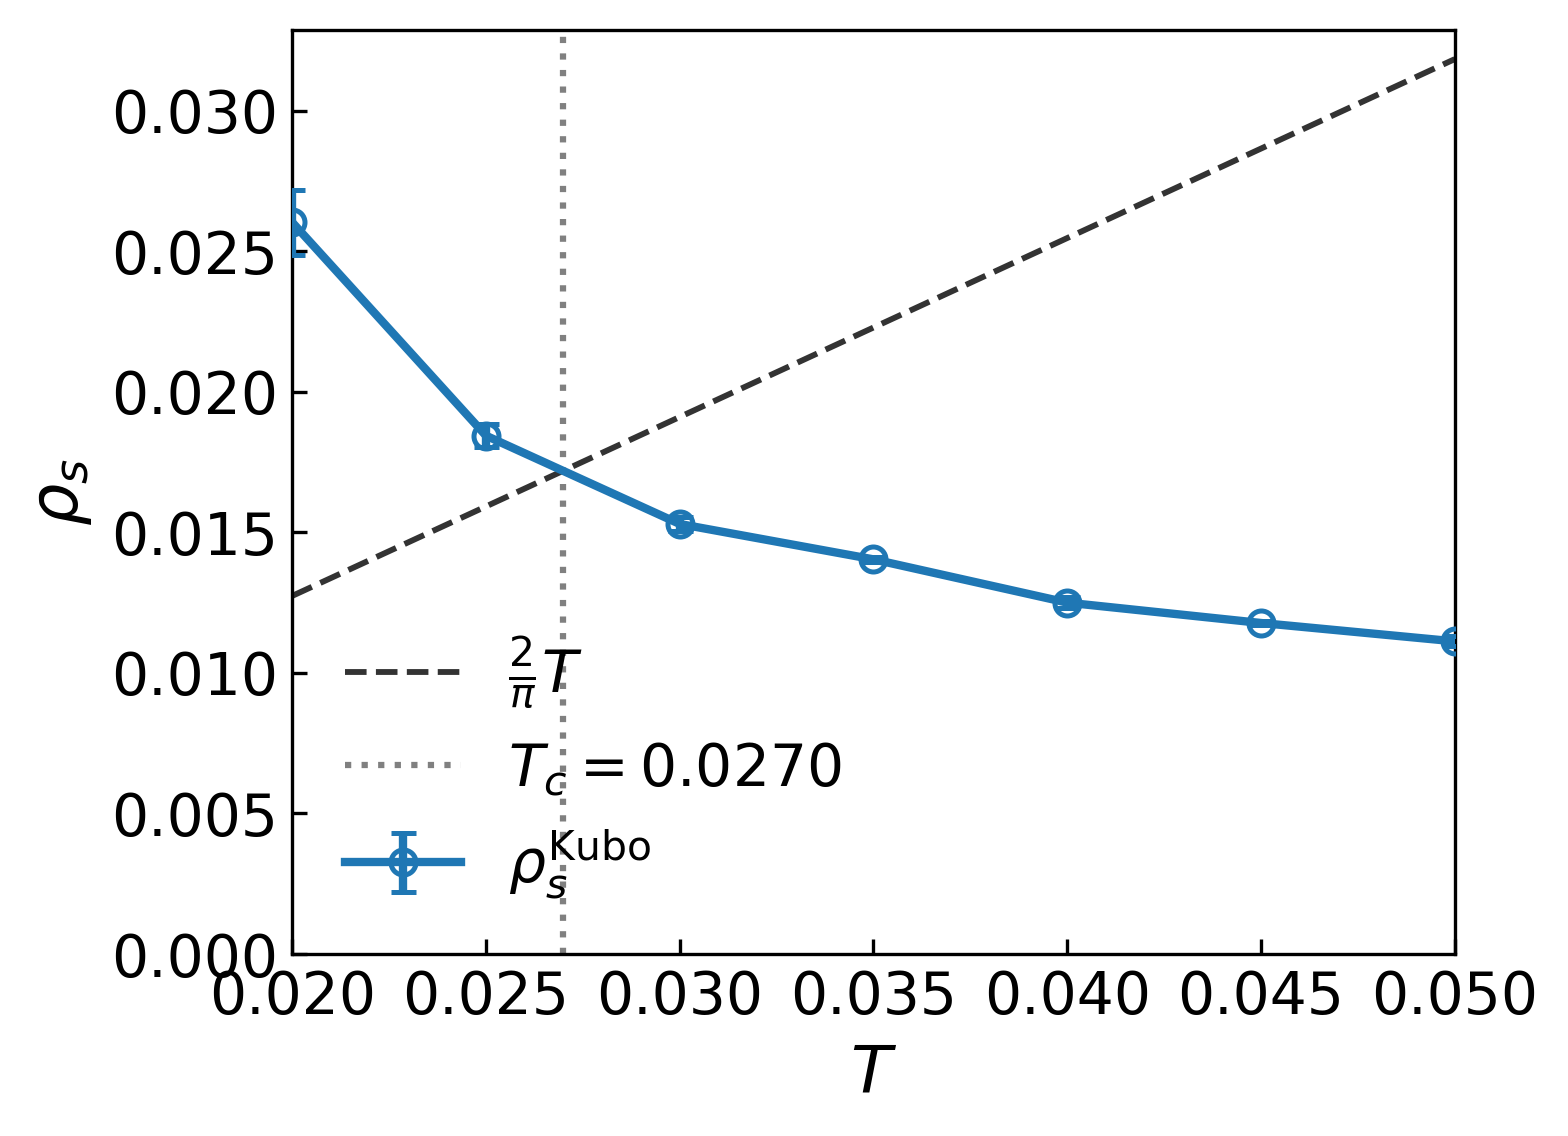

In [4]:
fig, ax = plt.subplots(dpi=300)

yerr = df[rho_err_col] if rho_err_col is not None else None
ax.errorbar(df['T'], df[rho_col], yerr=yerr,
            fmt='-o', capsize=3, color='tab:blue', markersize=6,
            markerfacecolor='none', fillstyle='none',
            markeredgecolor='tab:blue', markeredgewidth=1.2, zorder=3,
            label=r'$\rho_s^{\mathrm{Kubo}}$')

twist_candidates = [
    ('Stiffness_Twist_mean', 'Stiffness_Twist_err', r'$\rho_s^{\mathrm{twist}}$'),
    ('Twist_Qy_Rho_OffdiagCorrected_mean', 'Twist_Qy_Rho_OffdiagCorrected_err', r'$\rho_s^{\mathrm{twist}}$'),
    ('Stiffness_TwistRaw_mean', 'Stiffness_TwistRaw_err', r'$\rho_s^{\mathrm{twist}}$ raw curvature'),
    ('Twist_Qy_Rho_Curv_Avg_mean', 'Twist_Qy_Rho_Curv_Avg_err', r'$\rho_s^{\mathrm{twist}}$ raw curvature'),
]
found_twist = False
for twist_col, twist_err_col, twist_label in twist_candidates:
    if twist_col in df.columns:
        twist_yerr = df[twist_err_col] if twist_err_col in df.columns else None
        ax.errorbar(df['T'], df[twist_col], yerr=twist_yerr,
                    fmt='--s', capsize=3, color='tab:orange', markersize=7,
                    markerfacecolor='none', fillstyle='none',
                    markeredgecolor='tab:orange', markeredgewidth=1.2, alpha=0.9,
                    zorder=2, label=twist_label)
        found_twist = True
        break

if not found_twist:
    print('No twist stiffness columns found. Run batch_process_csv.jl after measure_twist=true jobs finish.')

T_line = np.linspace(df['T'].min(), df['T'].max(), 200)
rho_BKT = (2.0 / np.pi) * T_line
ax.plot(T_line, rho_BKT, linestyle='--', color='black', linewidth=1.4,
        alpha=0.8, label=r'$\frac{2}{\pi}T$')

if np.isfinite(Tc):
    ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5,
               label=rf'$T_c={Tc:.4f}$')

ax.set_xlabel(r'$T$')
ax.set_ylabel(r'$\rho_s$')
ax.set_xlim(0.02, 0.05)
ax.set_ylim(bottom=0)
ax.legend(loc='best', frameon=False)
plt.show()


No twist stiffness columns found. Run batch_process_csv.jl after measure_twist=true jobs finish.


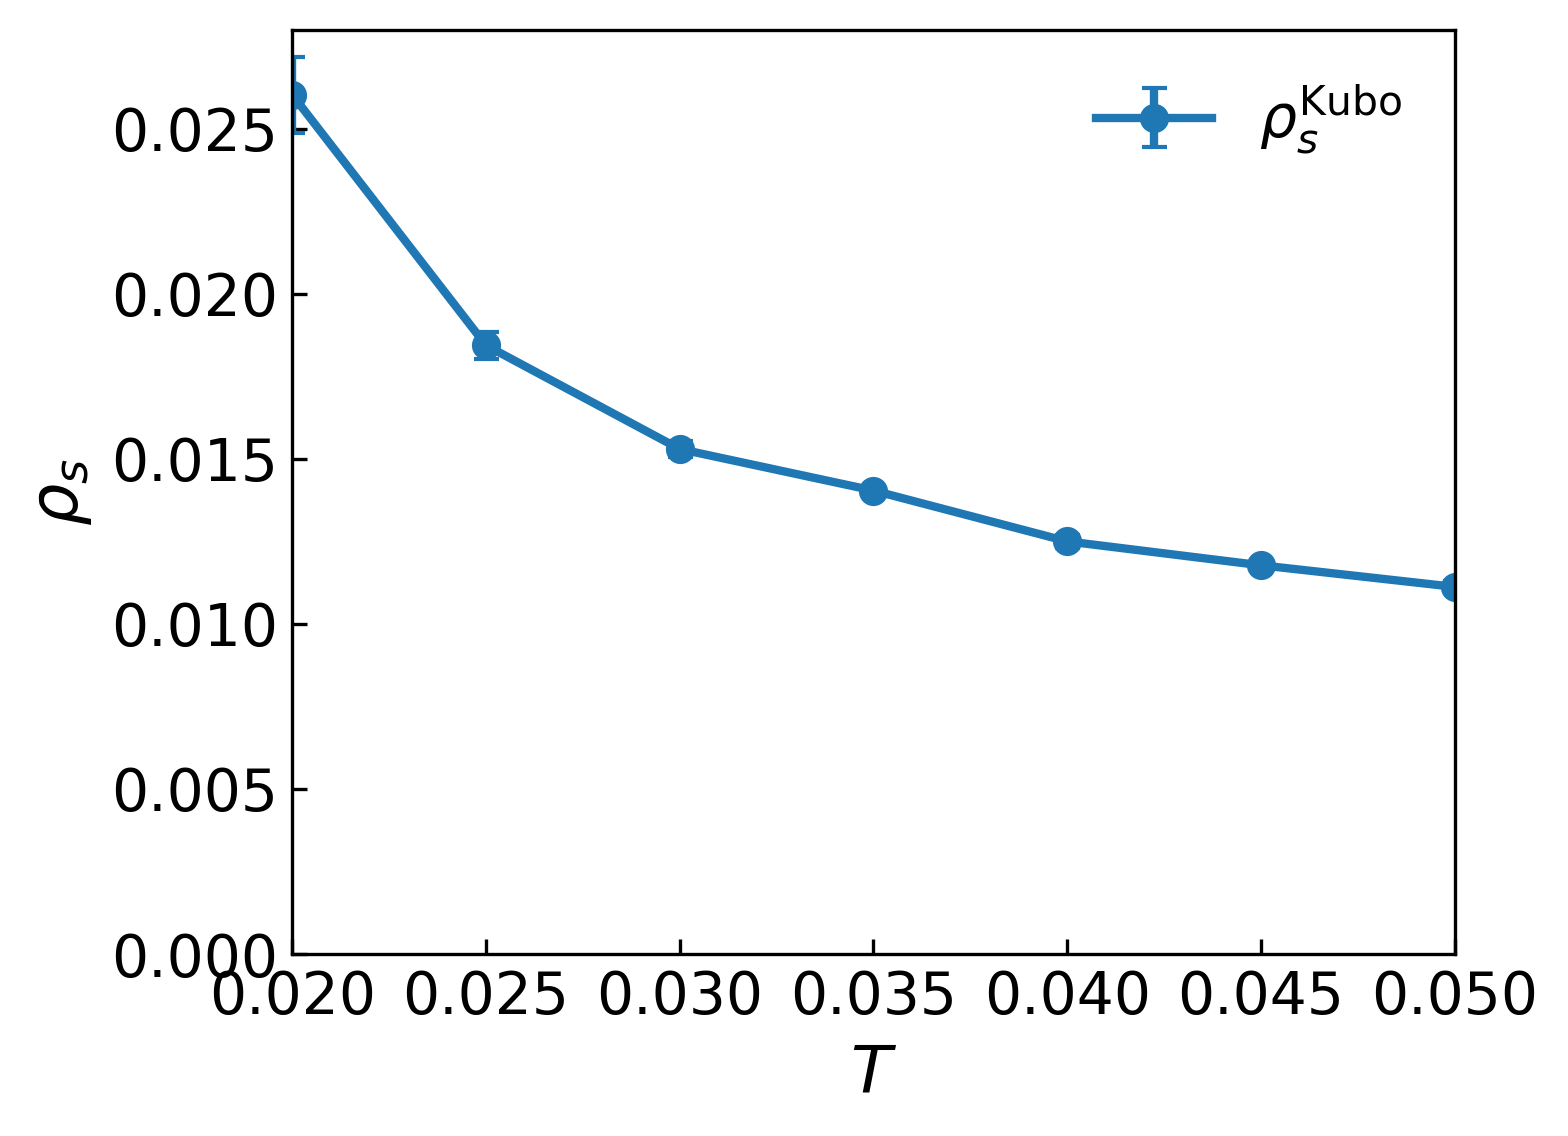

In [5]:
# Compare Kubo stiffness with twist free-energy curvature diagnostics.
# This cell is optional; run_simulation must be launched with measure_twist=true.

twist_candidates = [
    ('Stiffness_Twist_mean', 'Stiffness_Twist_err', r'$\rho_s^{\mathrm{twist}}$'),
    ('Twist_Qy_Rho_OffdiagCorrected_mean', 'Twist_Qy_Rho_OffdiagCorrected_err', r'$\rho_s^{\mathrm{twist}}$'),
    ('Stiffness_TwistRaw_mean', 'Stiffness_TwistRaw_err', r'$\rho_s^{\mathrm{twist}}$ raw curvature'),
    ('Twist_Qy_Rho_Curv_Avg_mean', 'Twist_Qy_Rho_Curv_Avg_err', r'$\rho_s^{\mathrm{twist}}$ raw curvature'),
]

fig, ax = plt.subplots(dpi=300)
ax.errorbar(df['T'], df['Superfluid_Stiffness_mean'],
            yerr=df['Superfluid_Stiffness_err'] if 'Superfluid_Stiffness_err' in df.columns else None,
            fmt='-o', capsize=3, color='tab:blue', label=r'$\rho_s^{\mathrm{Kubo}}$')

found_twist = False
for mean_col, err_col, label in twist_candidates:
    if mean_col in df.columns:
        ax.errorbar(df['T'], df[mean_col],
                    yerr=df[err_col] if err_col in df.columns else None,
                    fmt='--s', capsize=3, alpha=0.85, label=label)
        found_twist = True
        break

if not found_twist:
    print('No twist stiffness columns found. Run batch_process_csv.jl after measure_twist=true jobs finish.')

ax.set_xlabel(r'$T$')
ax.set_ylabel(r'$\rho_s$')
ax.set_xlim(0.02, 0.05)
ax.set_ylim(bottom=0)
ax.legend(loc='best', frameon=False)
plt.show()


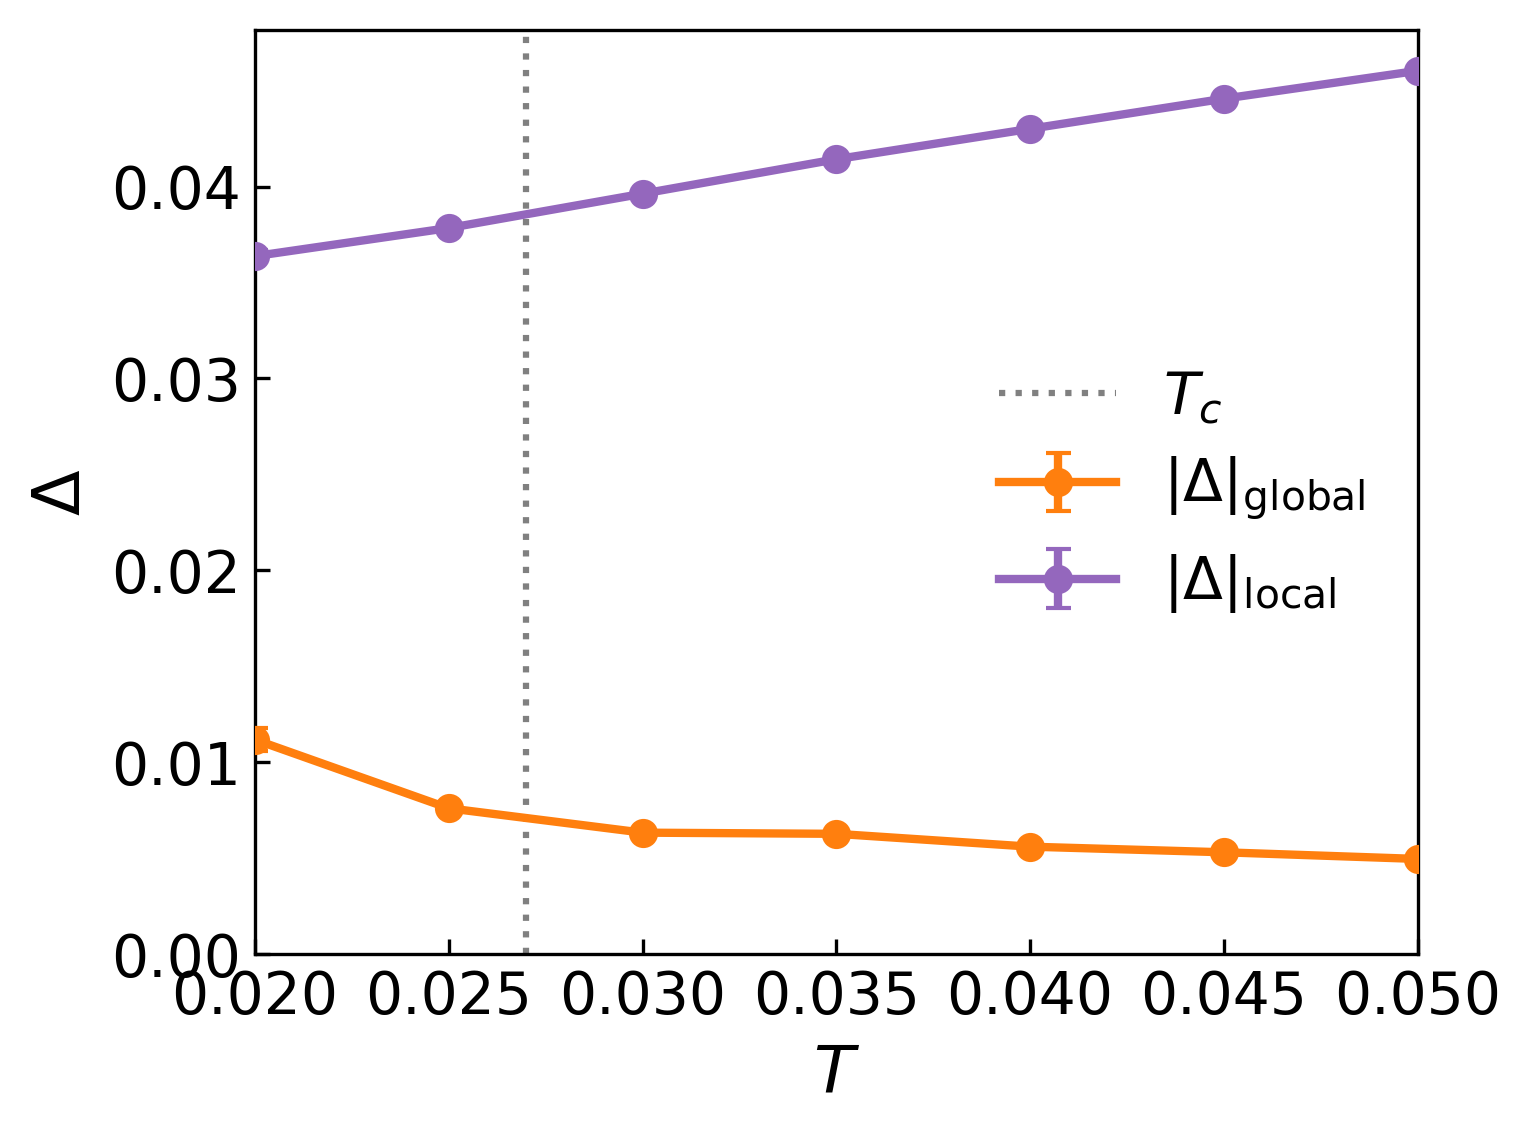

In [6]:
fig, ax = plt.subplots(dpi=300)

ax.errorbar(df['T'], df['Delta_Pair_mean'], yerr=df['Delta_Pair_err'], 
            fmt='-o', capsize=3, label=r'$|\Delta|_\mathrm{global}$', color='tab:orange', zorder=3)
ax.errorbar(df['T'], df['Delta_LocalPair_mean'], yerr=df['Delta_LocalPair_err'], 
            fmt='-o', capsize=3, label=r'$|\Delta|_\mathrm{local}$', color='tab:purple', zorder=3)

ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# 设置坐标轴
ax.set_xlabel(r'$T$')
ax.set_ylabel(r'$\Delta$')
ax.set_ylim(0,None) 
ax.set_xlim(0.02, 0.05)

ax.legend(loc='best', frameon=False)
plt.show()

In [7]:
# fig, ax = plt.subplots(dpi=300)

# ax.errorbar(df['T'], df['Delta_Loc_mean'], yerr=df['Delta_Loc_err'], 
#             fmt='-o', capsize=3, label=r'$|\Delta|_\mathrm{local-field}$', color='tab:red', zorder=3)
# ax.errorbar(df['T'], df['Delta_LocalPair_mean'], yerr=df['Delta_LocalPair_err'], 
#             fmt='-o', capsize=3, label=r'$|\Delta|_\mathrm{local}$', color='tab:purple', zorder=3)
# ax.errorbar(df['T'], df['Delta_LocalPair_mean']/df['Delta_Loc_mean'], yerr=df['Delta_LocalPair_err']/df['Delta_Loc_mean'], 
#             fmt='-o', capsize=3, label=r'$\chi_\mathrm{local}$', color='tab:blue', zorder=3)

# ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# # 设置坐标轴
# ax.set_xlabel(r'$T$')
# ax.set_ylabel(r'$\Delta$')
# ax.set_ylim(-0.002,1) 
# ax.set_xlim(0,0.08) 

# ax.legend(loc='best', frameon=False)
# plt.show()

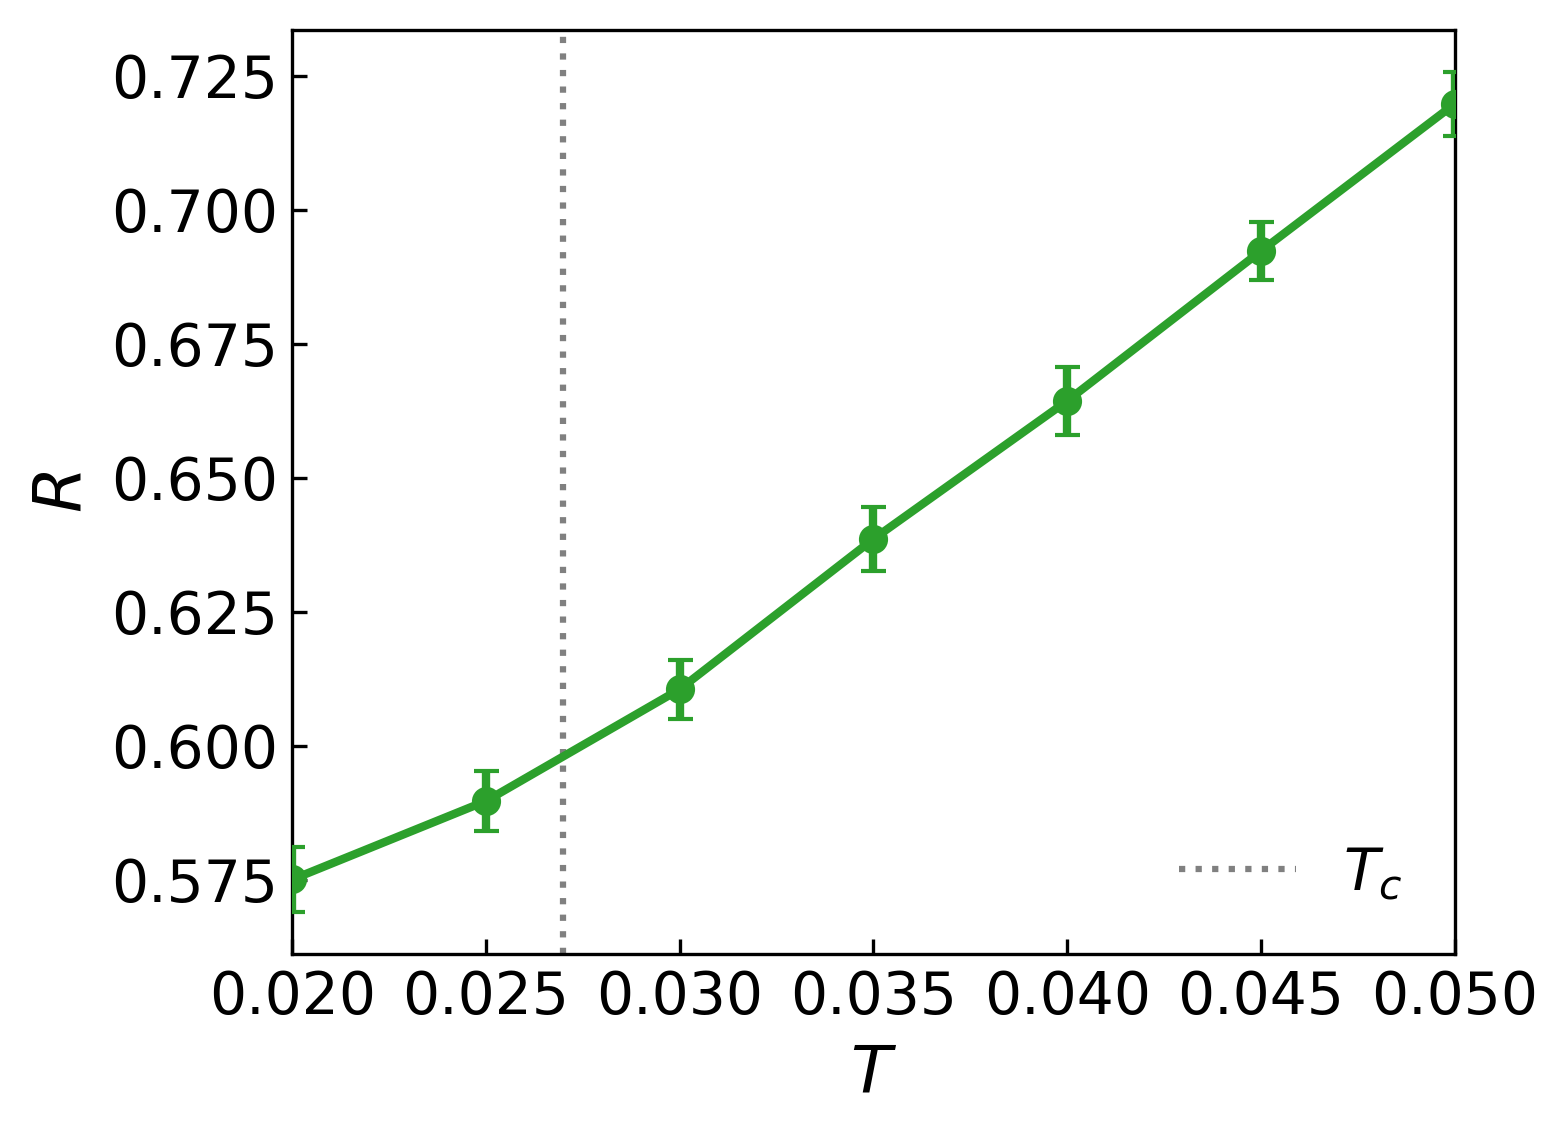

In [8]:
fig, ax = plt.subplots(dpi=300)

T_cut = 0.019
mask = df['T'] > T_cut
T = df.loc[mask, 'T']

rho_mean_col = 'Longitudinal_Resistivity_mean'
rho_err_col = 'Longitudinal_Resistivity_err'
hall_mean_col = 'Hall_Conductivity_mean'

if rho_mean_col in df.columns:
    R = df.loc[mask, rho_mean_col]
    R_err = df.loc[mask, rho_err_col] if rho_err_col in df.columns else None
    R_label = r'$\rho_{xx}$'
elif hall_mean_col in df.columns and 'DC_Conductivity_mean' in df.columns:
    sigma_xx = df.loc[mask, 'DC_Conductivity_mean'].to_numpy(dtype=float)
    sigma_xy = df.loc[mask, hall_mean_col].to_numpy(dtype=float)
    denom = sigma_xx * sigma_xx + sigma_xy * sigma_xy
    R = pd.Series(np.where(np.isfinite(denom) & (denom != 0.0), sigma_xx / denom, np.nan),
                  index=df.index[mask])
    R_err = None
    R_label = r'$\rho_{xx}$ from mean $\sigma$ tensor'
else:
    sigma = df.loc[mask, 'DC_Conductivity_mean']
    sigma_err = df.loc[mask, 'DC_Conductivity_err'] if 'DC_Conductivity_err' in df.columns else None
    R = 1.0 / sigma
    R_err = sigma_err / (sigma**2) if sigma_err is not None else None
    R_label = r'$1/\sigma_{xx}$ old-data proxy'

ax.errorbar(T, R, yerr=R_err,
            fmt='-o', capsize=3, color='tab:green', zorder=3,
            label=R_label)

ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')
ax.set_xlabel(r'$T$')
ax.set_ylabel(r'$\rho_{xx}$')
ax.set_xlim(0.02, 0.05)
ax.legend(loc='best', frameon=False)
plt.show()


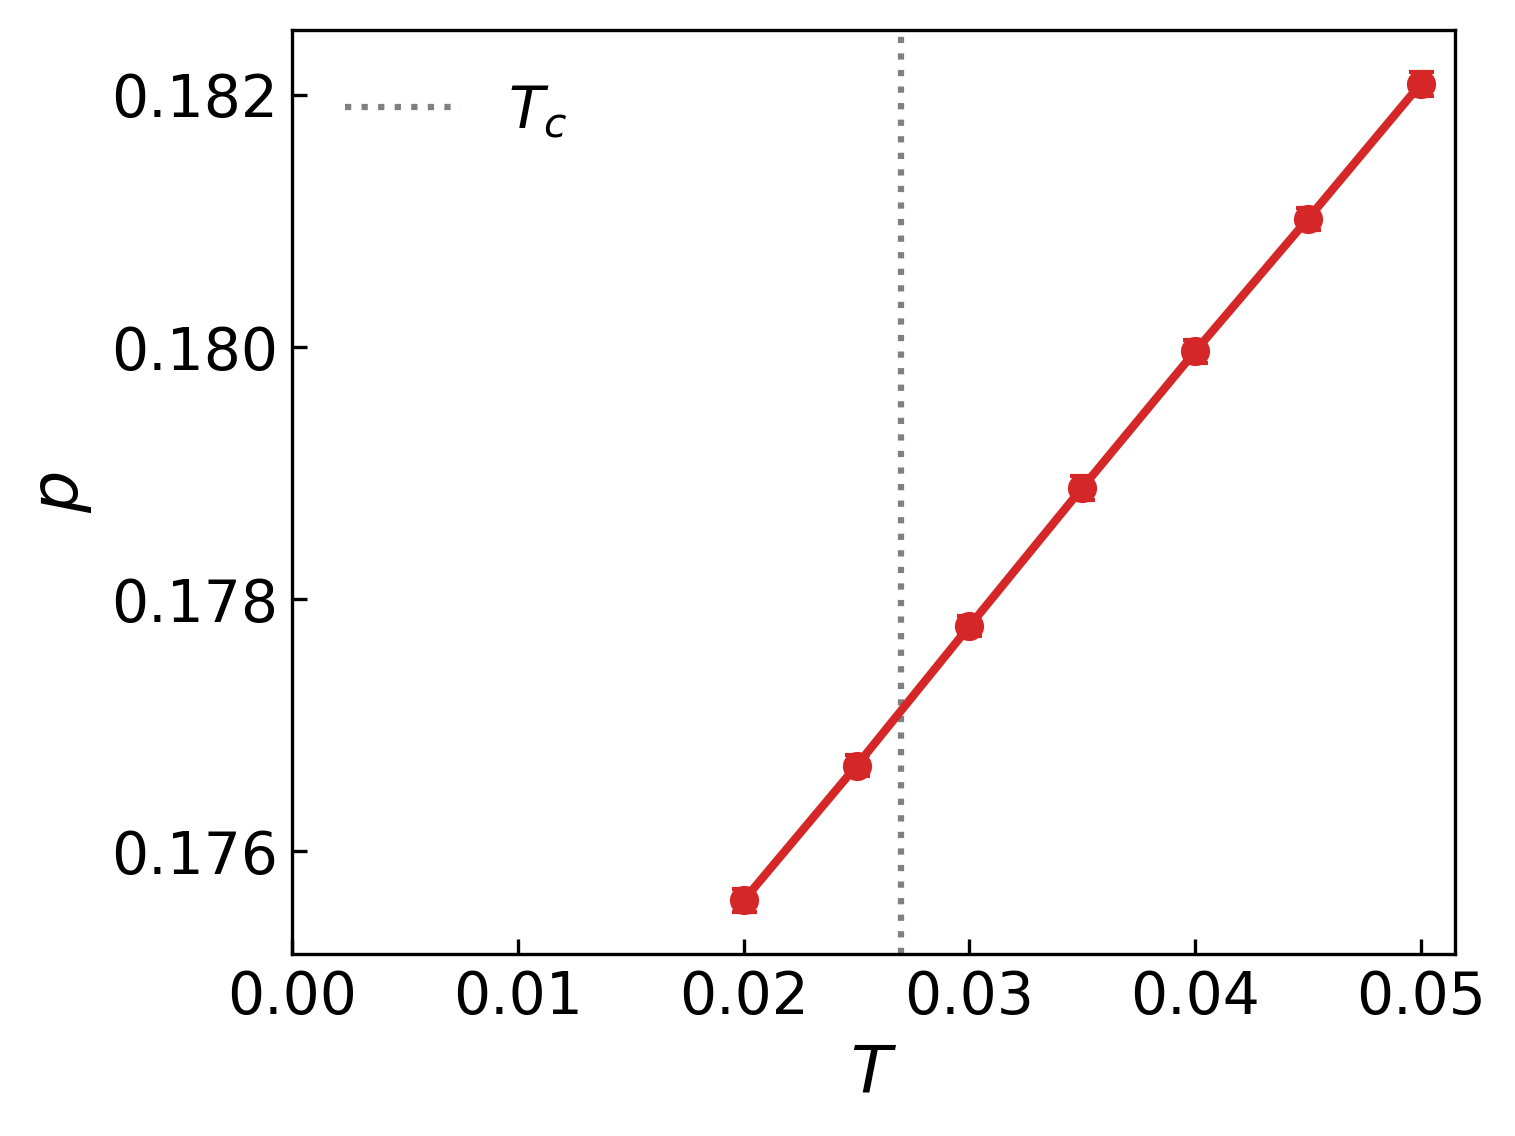

In [13]:
fig, ax = plt.subplots(dpi=300)

T = df['T'][:]
p = df['Hole_p_mean'][:]
p_err = df['Hole_p_err'][:]


ax.errorbar(T, p, yerr=p_err, 
            fmt='-o', capsize=3, color='tab:red', zorder=3)

ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# 设置坐标轴
ax.set_xlabel(r'$T$')
ax.set_ylabel(r'$p$')
# ax.set_ylim(0.241,0.264) 
ax.set_xlim(0,None) 

ax.legend(loc='best', frameon=False)
plt.show()

In [10]:
# fig, ax = plt.subplots(dpi=300)

# T = df['T'][df['T']>Tc]
# sigma = df['DC_Conductivity_mean'][df['T']>Tc]
# sigma_err = df['DC_Conductivity_err'][df['T']>Tc]
# p = df['Hole_p_mean'][df['T']>Tc]
# p_err = df['Hole_p_err'][df['T']>Tc]

# Rmp = 1 / sigma * p
# Rmp_err = sigma_err / (sigma**2) * p + p_err / sigma

# ax.errorbar(T, Rmp, yerr=Rmp_err, 
#             fmt='-o', capsize=3, color='tab:green', zorder=3)

# ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# # 设置坐标轴
# ax.set_xlabel(r'$T$')
# ax.set_ylabel(r'$Rp$')
# # ax.set_ylim(0.19,0.61) 
# # ax.set_xlim(0,0.1) 

# ax.legend(loc='best', frameon=False)
# plt.show()

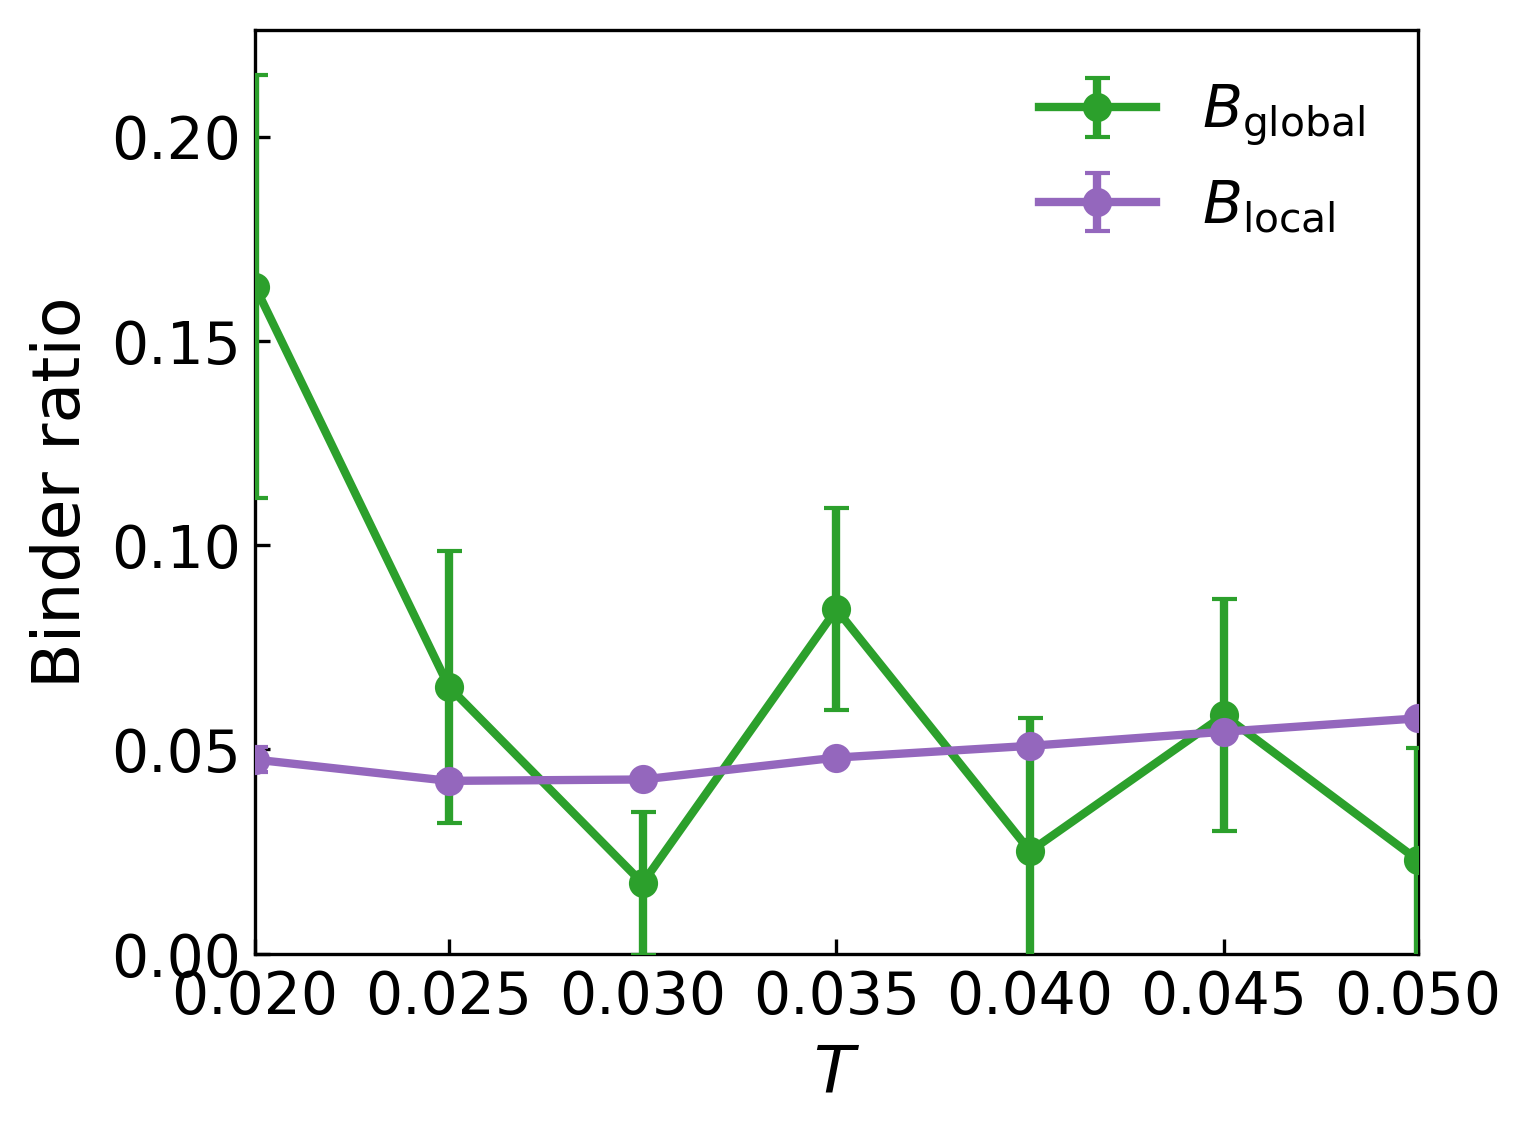

In [11]:
fig, ax = plt.subplots(dpi=300)

ax.errorbar(df['T'], df['B_global_mean'], yerr=df['B_global_err'],
            fmt='-o', capsize=3, label=r'$B_{\mathrm{global}}$', color='tab:green', zorder=3)
ax.errorbar(df['T'], df['B_local_mean'], yerr=df['B_local_err'],
            fmt='-o', capsize=3, label=r'$B_{\mathrm{local}}$', color='tab:purple', zorder=3)

# if 'Tc' in globals():
#     ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# temp
# ax.axvline(x=0.0001, color='black', linestyle='-', linewidth=1.5)
# ax.axhline(y=0, color='black', linestyle='--', linewidth=1.0)

ax.set_xlabel(r'$T$')
ax.set_ylabel(r'Binder ratio')
ax.set_ylim(0, None)
ax.set_xlim(0.02, 0.05)

ax.legend(loc='best', frameon=False)
plt.show()


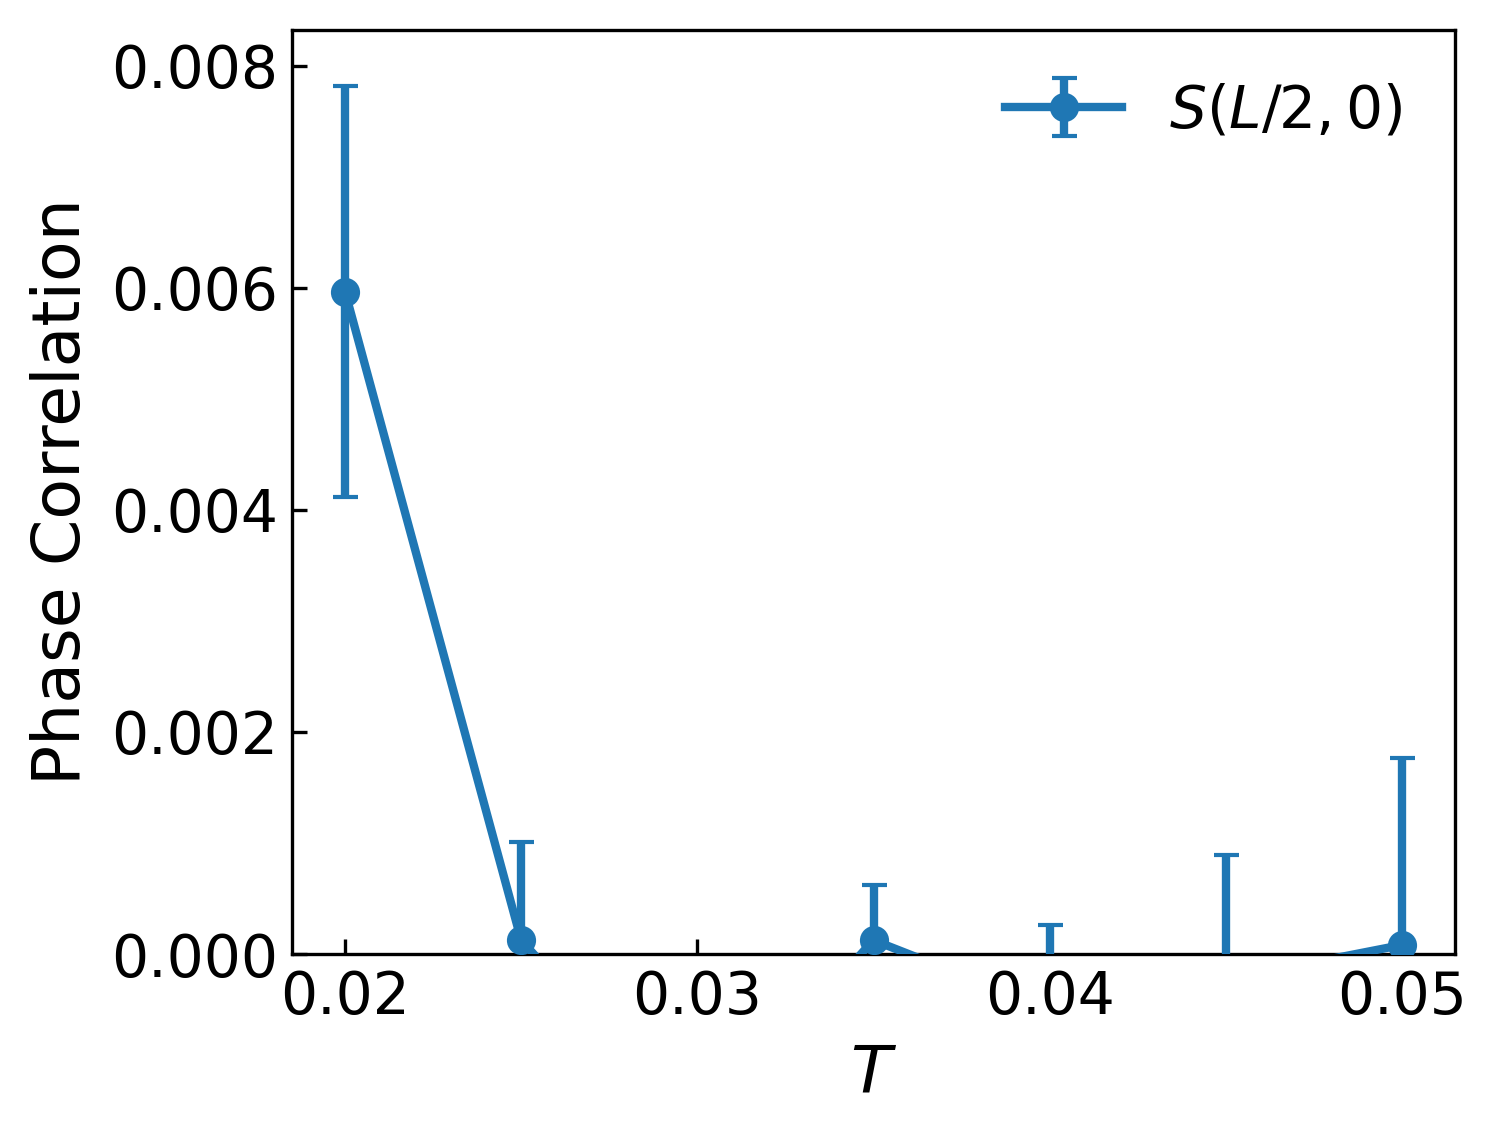

In [12]:
# Phase-correlation observable (default: S_L2_0)
fig, ax = plt.subplots(dpi=300)

ax.errorbar(df['T'], df['S_L2_0_mean'], yerr=df['S_L2_0_err'],
            fmt='-o', capsize=3, label=r'$S(L/2,0)$', color='tab:blue', zorder=3)

# Optional overlays:
# ax.errorbar(df['T'], df['S_1_0_mean'], yerr=df['S_1_0_err'],
#             fmt='-o', capsize=3, label=r'$S(1,0)$', color='tab:orange', zorder=3)
# ax.errorbar(df['T'], df['S_L2_L2_mean'], yerr=df['S_L2_L2_err'],
#             fmt='-o', capsize=3, label=r'$S(L/2,L/2)$', color='tab:green', zorder=3)
# ax.errorbar(df['T'], df['F_0_0_mean'], yerr=df['F_0_0_err'],
#             fmt='-o', capsize=3, label=r'$F(0,0)$', color='tab:red', zorder=3)

ax.set_xlabel(r'$T$')
ax.set_ylabel('Phase Correlation')
# ax.set_xlim(0, 0.08)
ax.set_ylim(bottom=0)
ax.legend(loc='best', frameon=False)
plt.show()
